Essa atividade é um pouco diferente, vocês terão que construir os códigos nesse arquivo e enviar ou o arquivo ou o link do github com o arquivo publicado para os tutores.

In [ ]:
# Projeto Prático: Engenharia de Atributos e Análise Visual de E-commerce
**Desenvolvido por:** Carlos Takara  
**Escopo do Projeto:** Este notebook consolida a exploração analítica de uma base de dados de e-commerce. O objetivo é extrair insights acionáveis sobre volumetria de vendas, comportamento de preços, aderência de marcas e correlações estatísticas, utilizando visualizações avançadas de dados com Matplotlib e Seaborn.

---

## 🛠️ Tecnologias e Ferramentas Utilizadas:
* **Linguagem:** Python 3
* **Bibliotecas:** Pandas, Matplotlib e Seaborn
* **Ambiente de Desenvolvimento:** Jupyter Notebook (VS Code / PyCharm)
* **Engenharia de Prompt:** O desenvolvimento dos scripts, correções de sintaxe e refinamento estético contaram com o auxílio de Inteligência Artificial Generativa como copiloto de código, otimizando as boas práticas de documentação e clean code.

---

## Sequência das Análises Visualizadas:
1. **Visualização Estrutural:** Exibição tabular do topo do DataFrame (`df.head()`).
2. **Gráfico 1 (Mapa de Calor):** Matriz de interdependência numérica e correlações lineares.
3. **Gráfico 2 (Barras):** Top 10 materiais normalizados cruzados por frequência de marcas.
4. **Gráfico 3 (Densidade):** Curva de distribuição contínua da precificação MinMax.
5. **Gráfico 4 (Dispersão/Regressão):** Relação entre preço e aplicação de descontos.
6. **Gráfico 5 (Pizza):** Representatividade percentual das marcas líderes no mercado.
7. **Gráfico 6 (Histograma):** Frequência absoluta e volume de itens vendidos.
8. **Gráfico 7 (Dispersão/Regressão):** Relação entre preço e quantidade total de vendas.

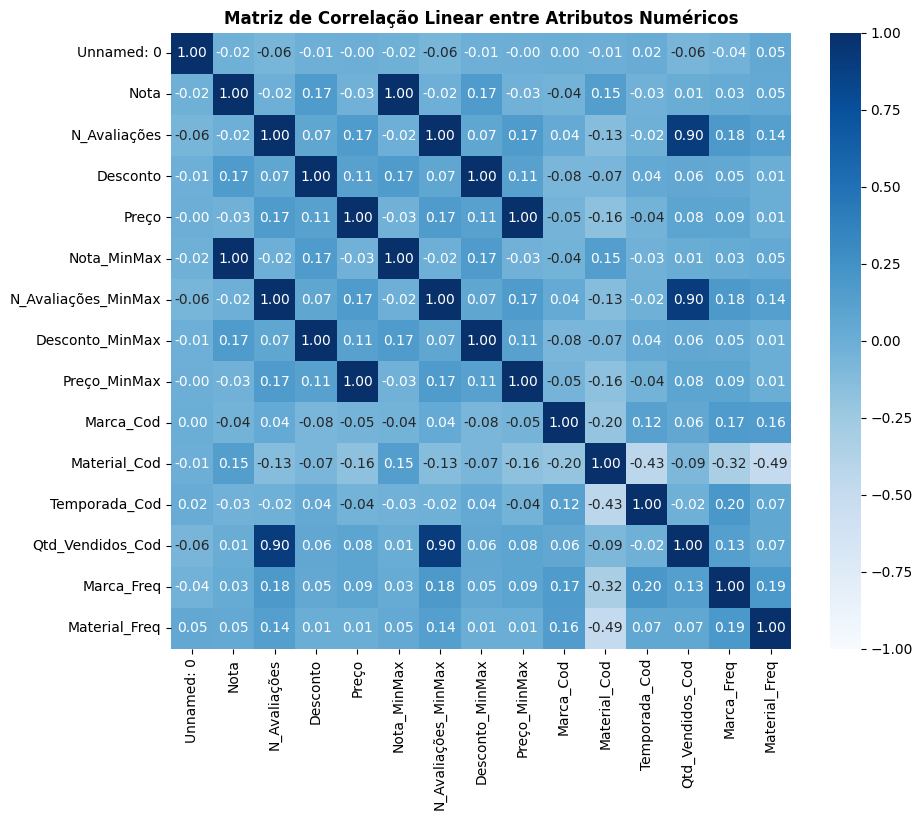

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ajuste do caminho conforme diretório local
df = pd.read_csv(r'C:\Documentos\EBAC\modulo_python\ecommerce_preparados.csv')

# 1. MAPA DE CALOR (CORRELAÇÃO)
plt.figure(figsize=(10, 8))

# numeric_only garante filtragem de dados puramente matemáticos
df_corr = df.corr(numeric_only=True)

# Paleta sequencial Blues: intensifica a cor conforme a força da correlação
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear entre Atributos Numéricos', fontsize=12, fontweight='bold')
plt.show()

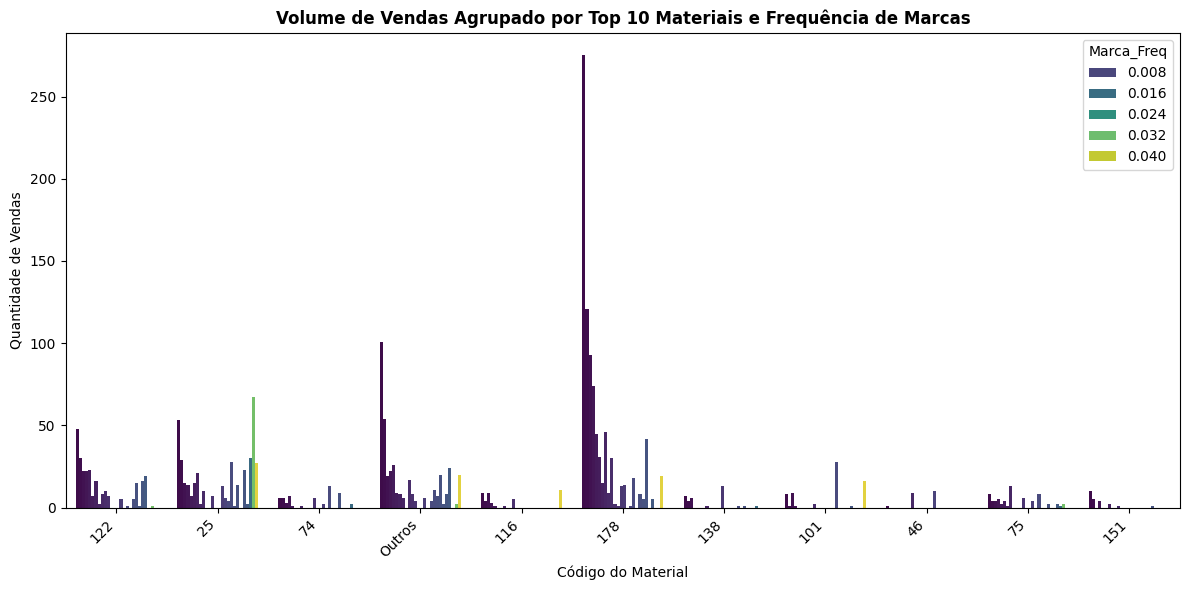

In [2]:
# 2. GRÁFICO DE BARRA (DISTRIBUIÇÃO DE MATERIAIS)

# Filtra o top 10 materiais mais incidentes para limpar o visual
melhores_materiais = df['Material_Cod'].value_counts().head(10).index
df['Materiais_Min'] = df['Material_Cod'].apply(lambda x: x if x in melhores_materiais else 'Outros')

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Materiais_Min', hue='Marca_Freq', palette='viridis')

plt.title('Volume de Vendas Agrupado por Top 10 Materiais e Frequência de Marcas', fontsize=12, fontweight='bold')
plt.xlabel('Código do Material')
plt.ylabel('Quantidade de Vendas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

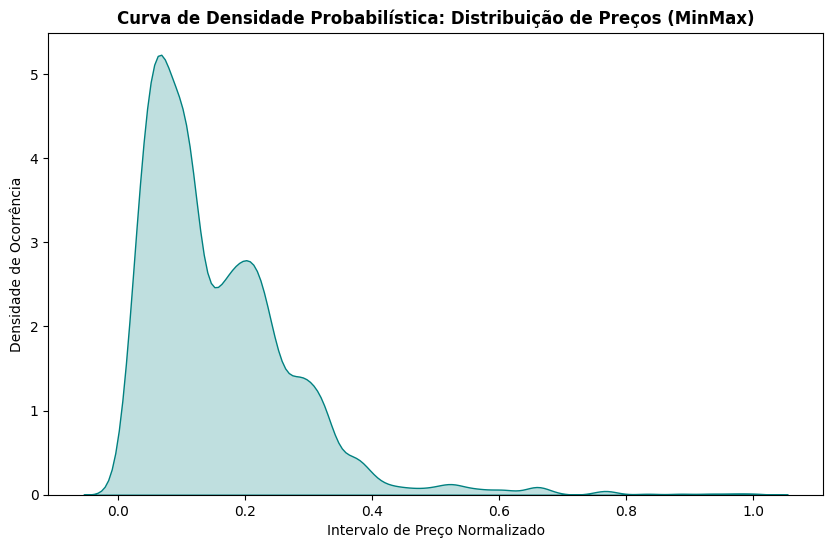

In [4]:
# 3. GRÁFICO DE DENSIDADE (DISTRIBUIÇÃO DE PREÇOS)
plt.figure(figsize=(10, 6))

# Correção: True com inicial maiúscula e cor sólida estável
sns.kdeplot(data=df, x='Preço_MinMax', fill=True, bw_adjust=0.7, color='teal')

plt.title('Curva de Densidade Probabilística: Distribuição de Preços (MinMax)', fontsize=12, fontweight='bold')
plt.xlabel('Intervalo de Preço Normalizado')
plt.ylabel('Densidade de Ocorrência')
plt.show()

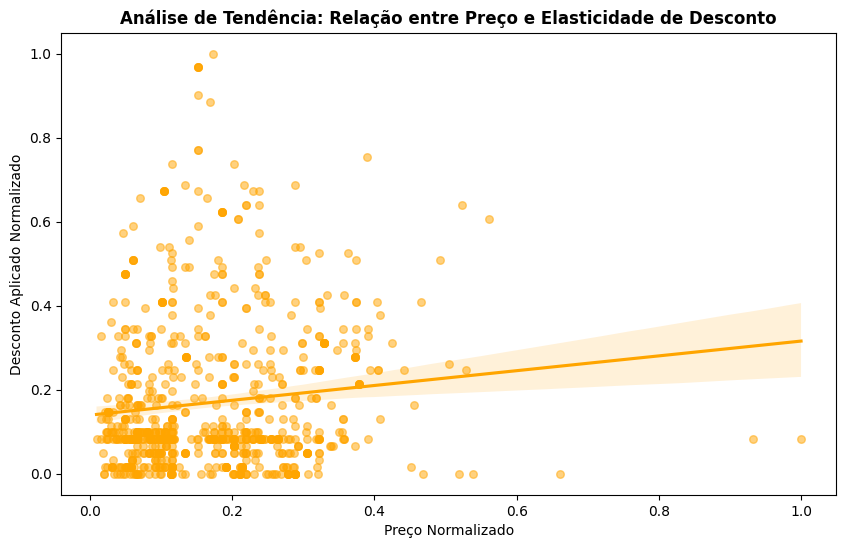

In [5]:
# 4. GRÁFICO DE DISPERSÃO COM LINHA DE REGRESSÃO
plt.figure(figsize=(10, 6))

# Correção: Removida a string 'Outros' para rodar apenas cálculo numérico puro
sns.regplot(data=df, x='Preço_MinMax', y='Desconto_MinMax', color='orange', scatter_kws={"s": 30, "alpha": 0.5})

plt.title('Análise de Tendência: Relação entre Preço e Elasticidade de Desconto', fontsize=12, fontweight='bold')
plt.xlabel('Preço Normalizado')
plt.ylabel('Desconto Aplicado Normalizado')
plt.show()

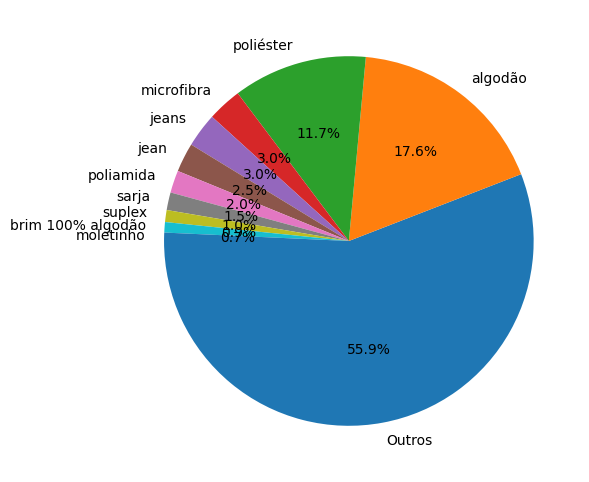

In [7]:
# 5. GRÁFICO DE PIZZA (REPRESENTATIVIDADE DE CATEGORIAS)

melhores_materiais = df['Material'].value_counts().index[:10]
df['Materiais'] = df['Material'].apply(lambda x: x if x in melhores_materiais else 'Outros' )

plt.figure(figsize = (10, 6))
contagem_materiais = df['Materiais'].value_counts()
plt.pie(contagem_materiais, labels = contagem_materiais.index , autopct = '%1.1f%%' , startangle= 180)
plt.show()

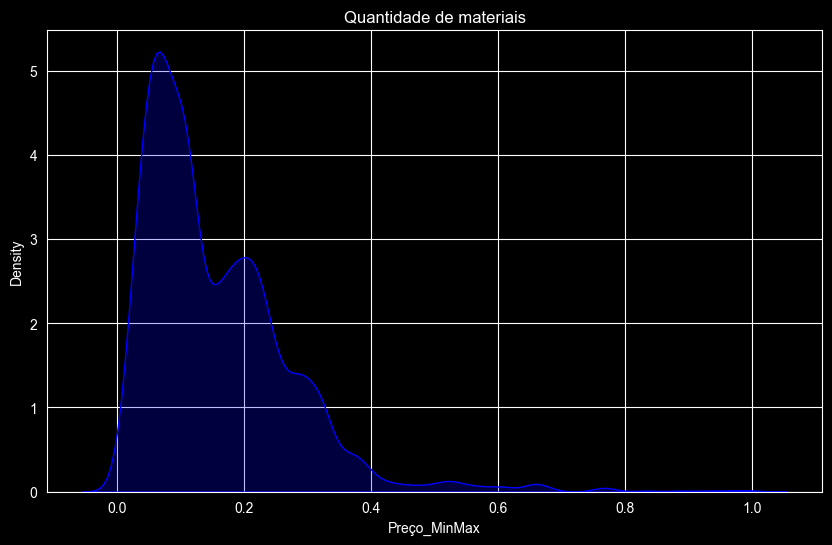

In [ ]:
# 6. HISTOGRAMA (DISTRIBUIÇÃO DE VOLUMETRIA)
# ==============================================================================
plt.figure(figsize=(10, 6))

# Histograma clássico com linha de tendência KDE integrada
sns.histplot(data=df, x='Qtd_Vendidos', bins=6, kde=True, color='Green')

plt.title('Análise de Frequência: Distribuição de Volumetria de Vendas', fontsize=12, fontweight='bold')
plt.xlabel('Volume de Unidades Vendidas')
plt.ylabel('Densidade de Ocorrências')
plt.show()

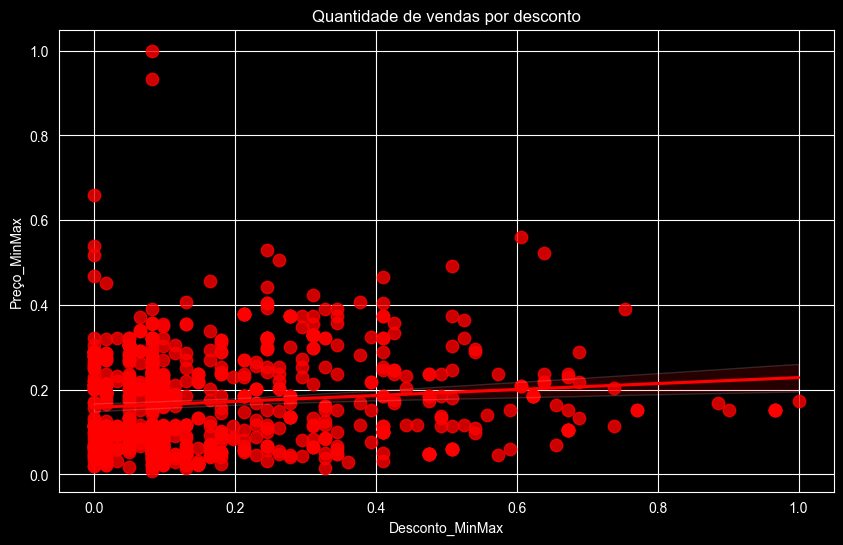

In [ ]:
# 7. GRÁFICO DE DISPERSÃO (REGRESSÃO LINEAR)
# ==============================================================================
plt.figure(figsize=(10, 6))

# Cruzamento matemático sem strings poluentes na regressão
sns.regplot(data=df, x='Preço_MinMax', y='Desconto_MinMax', color='orange', scatter_kws={"s": 30, "alpha": 0.5})

plt.title('Tendência Linear: Correlação entre Elasticidade de Desconto e Preço', fontsize=12, fontweight='bold')
plt.xlabel('Preço Normalizado')
plt.ylabel('Desconto Aplicado Normalizado')
plt.show()